In [260]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from scipy.misc import derivative
import pandas as pd

In [261]:
# === Laplace Coefficient b_{1/2}^{(j)}(alpha) ===
def laplace_b_12(alpha, j):
    integrand = lambda theta: np.cos(j * theta) / np.sqrt(1 - 2 * alpha * np.cos(theta) + alpha**2)
    result, _ = quad(integrand, 0, 2 * np.pi, limit=1000)
    return result / np.pi

# === Derivative operator D_alpha b = alpha * db/dalpha ===
def D_alpha_b(alpha, j, h=1e-5):
    db_dalpha = derivative(lambda a: laplace_b_12(a, j), alpha, dx=h, order=5)
    return alpha * db_dalpha

# === f_j^{(1)} for the inner planet ===
def f_j_inner(alpha, j, P1, P2):
    delta_j1 = 1 if j == 1 else 0
    n1 = (2*np.pi)/P1
    n2 = (2*np.pi)/P2
    # beta = j * (1 - P1 / P2)
    beta = j*((n1-n2)/n1)

    b = laplace_b_12(alpha, j)
    D_b = D_alpha_b(alpha, j)

    denominator = beta**2 * (beta**2 - 1)
    if denominator == 0:
        return 0  # avoid resonance divergence

    numerator = 2 * beta * D_b + j * (3 + beta**2) * b - alpha * delta_j1 * (beta**2 + 2 * beta + 3)

    return alpha * numerator / denominator

# === f_j^{(2)} for the outer planet ===
def f_j_outer(alpha, j, P1, P2):
    delta_j1 = 1 if j == 1 else 0
    n1 = (2*np.pi)/P1
    n2 = (2*np.pi)/P2
    kappa = j*((n1-n2)/n2)
    # kappa = j * (P2 - P1) / P1

    b = laplace_b_12(alpha, j)
    D_b = D_alpha_b(alpha, j)

    denominator = kappa**2 * (kappa**2 - 1)
    if denominator == 0:
        return 0  # avoid resonance divergence

    numerator = j * (kappa**2 + 3) * b + 2 * kappa * (D_b + b) - alpha**(-2) * delta_j1 * (kappa**2 - 2 * kappa + 3)

    return numerator / denominator



In [262]:
# === Synodic chopping TTV model ===
def synodic_chopping_ttv(t, P1, P2, m2_over_Mstar, alpha, t0, transiting='inner', jmax=5):
    synodic_angle = (2 * np.pi * ((1 / P1) - (1 / P2))) * (t-t0)
    ttv = np.zeros_like(t)

    for j in range(1, jmax + 1):
        phase = j * synodic_angle
        if transiting == 'inner':
            f_j = f_j_inner(alpha, j, P1, P2)
            ttv += (P1 / (np.pi * j)) * m2_over_Mstar * f_j * np.sin(phase)
        elif transiting == 'outer':
            f_j = f_j_outer(alpha, j, P1, P2)
            ttv += (P2 / (np.pi * j)) * m2_over_Mstar * f_j * np.sin(phase)

    return ttv


In [263]:
from astropy.constants import M_sun, M_earth, G
M_star = 0.81 * M_sun.value
# approximate masses from nasa exoplanet archive polanski 2024
m1 = 6.1 * M_earth.value
m2 = 2.2 * M_earth.value

In [264]:
# System parameters
P_inner = 28.579889             # Period of transiting planet [days]
P_outer = 38.352562             # Period of perturber planet [days]
alpha = (P_inner / P_outer)**(2./3.)       # Semi-major axis ratio for circular orbits
m_inner_over_Mstar = m1 / M_star
m_outer_over_Mstar = m2 / M_star # Mass ratio of perturber to star
jmax = 1             # Max harmonic in the chopping sum


In [265]:
P_syn = 1 / ((1/P_inner) - (1/P_outer))
print(f'synodic period: {P_syn} days')

synodic period: 112.16091695952764 days


In [266]:
# Time array for computing TTVs
times = np.linspace(1726.04, 3661.11, 3000)

In [267]:
# Compute inner planet chopping signal
ttv_inner = synodic_chopping_ttv(times, P_inner, P_outer, m_outer_over_Mstar, alpha, 1726.054975, transiting='inner', jmax=jmax)


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_78658/3783278219.py:9: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  db_dalpha = derivative(lambda a: laplace_b_12(a, j), alpha, dx=h, order=5)


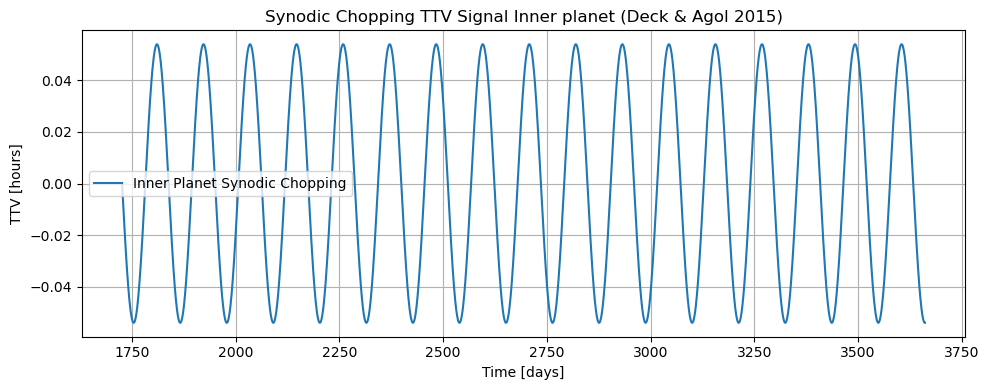

In [268]:
# Plot TTV signal 
plt.figure(figsize=(10, 4))
plt.plot(times, ttv_inner * 24, label='Inner Planet Synodic Chopping')
plt.xlabel('Time [days]')
plt.ylabel('TTV [hours]')
plt.title('Synodic Chopping TTV Signal Inner planet (Deck & Agol 2015)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [269]:
# Compute inner planet chopping signal
ttv_outer = synodic_chopping_ttv(times, P_inner, P_outer, m_inner_over_Mstar, alpha, 1743.552833, transiting='outer', jmax=jmax)


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_78658/3783278219.py:9: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  db_dalpha = derivative(lambda a: laplace_b_12(a, j), alpha, dx=h, order=5)


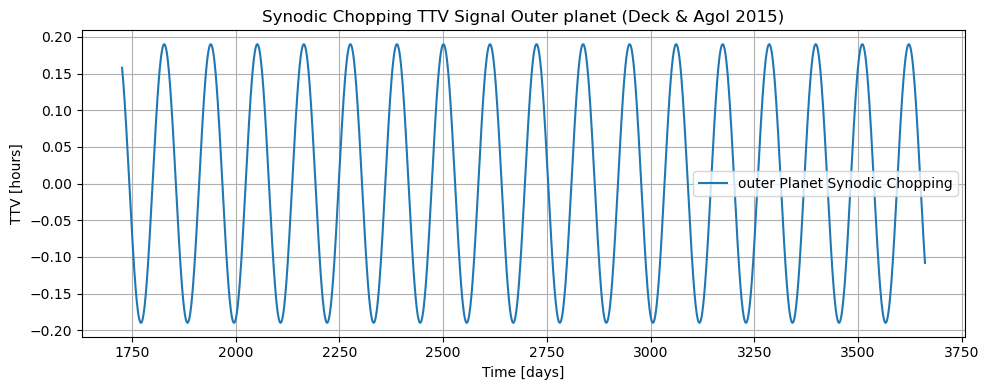

In [270]:
# Plot TTV signal 
plt.figure(figsize=(10, 4))
plt.plot(times, ttv_outer * 24, label='outer Planet Synodic Chopping')
plt.xlabel('Time [days]')
plt.ylabel('TTV [hours]')
plt.title('Synodic Chopping TTV Signal Outer planet (Deck & Agol 2015)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

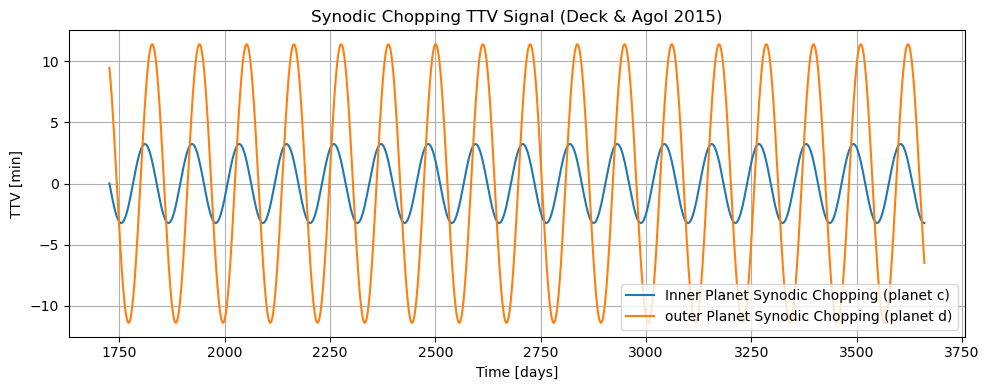

In [271]:
# Plot TTV signal 
plt.figure(figsize=(10, 4))
plt.plot(times, ttv_inner * 24*60, label='Inner Planet Synodic Chopping (planet c)')
plt.plot(times, ttv_outer * 24*60, label='outer Planet Synodic Chopping (planet d)')
plt.xlabel('Time [days]')
plt.ylabel('TTV [min]')
plt.title('Synodic Chopping TTV Signal (Deck & Agol 2015)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# load in transit data

In [187]:
df = pd.read_csv("data_1339/toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_78658/2846524796.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


In [188]:
print(df)

    Planet_num  Index           Tc    Tc_err
0            2      0  1726.054975  0.002286
1            2      1  1754.634044  0.001203
2            2      2  1783.211479  0.001701
3            2      3  1811.800043  0.001701
4            2      4  1840.375325  0.000472
5            2      6  1897.535247  0.002019
6            2      7  1926.116447  0.001668
7            2     25  2440.545208  0.001454
8            2     32  2640.606524  0.001926
9            2     34  2697.771841  0.001416
10           2     35  2726.353066  0.003117
11           2     38  2812.096804  0.002137
12           2     39  2840.672750  0.001203
13           2     42  2926.419096  0.001711
14           2     55  3297.970702  0.002137
15           2     57  3355.129798  0.000746
16           2     58  3383.710439  0.001180
17           2     60  3440.876620  0.001668
18           2     64  3555.195637  0.001203
19           2     65  3583.771809  0.001492
20           2     66  3612.350021  0.002170
21        

In [227]:
indices_2 = df[df['Planet_num'] == 2]['Index'].tolist()
transit_times_2 = df[df['Planet_num'] == 2]['Tc'].tolist()
tc_err_2 = df[df['Planet_num'] == 2]['Tc_err'].tolist()
indices_2 = np.array(indices_2)
transit_times_2 = np.array(transit_times_2)
tc_err_2 = np.array(tc_err_2)

indices_3 = df[df['Planet_num'] == 3]['Index'].tolist()
transit_times_3 = df[df['Planet_num'] == 3]['Tc'].tolist()
tc_err_3 = df[df['Planet_num'] == 3]['Tc_err'].tolist()
indices_3 = np.array(indices_3)
transit_times_3 = np.array(transit_times_3)
tc_err_3 = np.array(tc_err_3)

In [228]:
# Linear ephemeris model
def linear_ephemeris(n, T0, P):
    return T0 + n * P

In [229]:
# Fit model using curve_fit
popt_2, pcov_2 = curve_fit(linear_ephemeris, indices_2, transit_times_2, sigma=tc_err_2, absolute_sigma=True)
T0_fit_2, P_fit_2 = popt_2
T0_err_2, P_err_2 = np.sqrt(np.diag(pcov_2))
P_inner = P_fit_2
print(f"Planet 2 Linear Ephemeris Fit:")
print(f"  T0 = {T0_fit_2:.6f} ± {T0_err_2:.6f} days")
print(f"  P  = {P_fit_2:.8f} ± {P_err_2:.8f} days")

Planet 2 Linear Ephemeris Fit:
  T0 = 1726.052433 ± 0.000401 days
  P  = 28.58027007 ± 0.00001061 days


In [230]:
popt_3, pcov_3 = curve_fit(linear_ephemeris, indices_3, transit_times_3, sigma=tc_err_3, absolute_sigma=True)
T0_fit_3, P_fit_3 = popt_3
T0_err_3, P_err_3 = np.sqrt(np.diag(pcov_3))
P_outer = P_fit_3
print(f"Planet 3 Linear Ephemeris Fit:")
print(f"  T0 = {T0_fit_3:.6f} ± {T0_err_3:.6f} days")
print(f"  P  = {P_fit_3:.8f} ± {P_err_3:.8f} days")

Planet 3 Linear Ephemeris Fit:
  T0 = 1743.560958 ± 0.000603 days
  P  = 38.35160784 ± 0.00002431 days


In [231]:
T0_2 = transit_times_2[0] 
print(T0_2)
linear_ephemeris_2 = T0_fit_2 + indices_2 * P_fit_2

T0_3 = transit_times_3[0] 
linear_ephemeris_3 = T0_fit_3 + indices_3 * P_fit_3

1726.05497471


In [232]:
m_perturber_over_Mstar_2 = m_outer_over_Mstar
ttv_model_2 = synodic_chopping_ttv(
    transit_times_2,
    P_inner,
    P_outer,
    m_perturber_over_Mstar_2,
    alpha,
    transiting='inner',
    jmax=jmax
)

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_78658/4118552350.py:9: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  db_dalpha = derivative(lambda a: laplace_b_12(a, j), alpha, dx=h, order=5)


In [233]:
model_transit_times_2 = linear_ephemeris_2 #+ ttv_model_2

In [234]:
residuals_2 = transit_times_2 - model_transit_times_2 

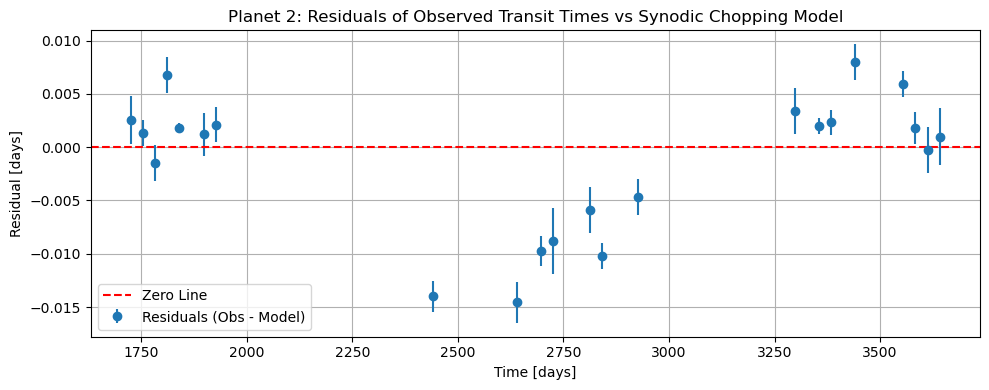

In [235]:
plt.figure(figsize=(10, 4))
plt.errorbar(transit_times_2, residuals_2, yerr=tc_err_2, fmt='o', label='Residuals (Obs - Model)')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Time [days]')
plt.ylabel('Residual [days]')
plt.title('Planet 2: Residuals of Observed Transit Times vs Synodic Chopping Model')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [236]:
m_perturber_over_Mstar_3 = m_inner_over_Mstar
ttv_model_3 = synodic_chopping_ttv(
    transit_times_3,
    P_inner,
    P_outer,
    m_perturber_over_Mstar_3,
    alpha,
    transiting='outer',
    jmax=jmax
)

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_78658/4118552350.py:9: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  db_dalpha = derivative(lambda a: laplace_b_12(a, j), alpha, dx=h, order=5)


In [237]:
model_transit_times_3 = linear_ephemeris_3 #+ ttv_model_3

In [238]:
residuals_3 = transit_times_3 - model_transit_times_3 

In [273]:
ttv_chop_j1_obs = synodic_chopping_ttv(t_obs, P_fit, P_outer, m2M_fit, alpha, transiting='inner', jmax=1)
ttv_chop_j1_obs = ttv_chop_j1_obs #* 24 * 60  # convert to minutes

TypeError: synodic_chopping_ttv() missing 1 required positional argument: 't0'

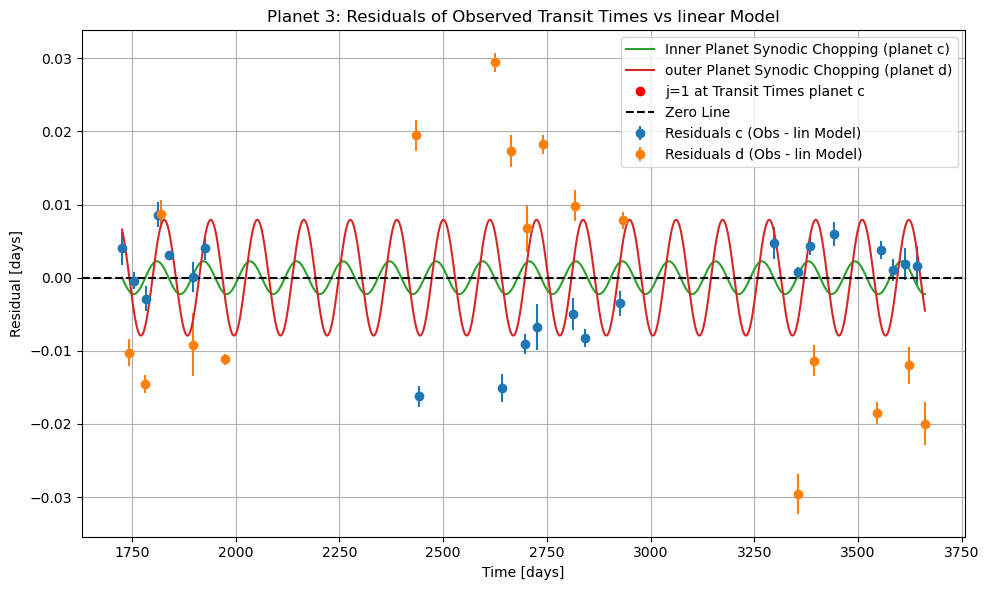

In [272]:
plt.figure(figsize=(10, 6))
plt.errorbar(transit_times_2, residuals_2, yerr=tc_err_2, fmt='o', label='Residuals c (Obs - lin Model)')
plt.errorbar(transit_times_3, residuals_3, yerr=tc_err_3, fmt='o', label='Residuals d (Obs - lin Model)')
plt.plot(times, ttv_inner, label='Inner Planet Synodic Chopping (planet c)')
plt.plot(times, ttv_outer, label='outer Planet Synodic Chopping (planet d)')

plt.plot(transit_times_2, ttv_chop_j1_obs, 'ro', label='j=1 at Transit Times planet c')

plt.axhline(0, color='black', linestyle='--', label='Zero Line')
plt.xlabel('Time [days]')
plt.ylabel('Residual [days]')
plt.title('Planet 3: Residuals of Observed Transit Times vs linear Model')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [240]:
residuals_2 = residuals_2 - ttv_model_2
residuals_3 = residuals_3 - ttv_model_3

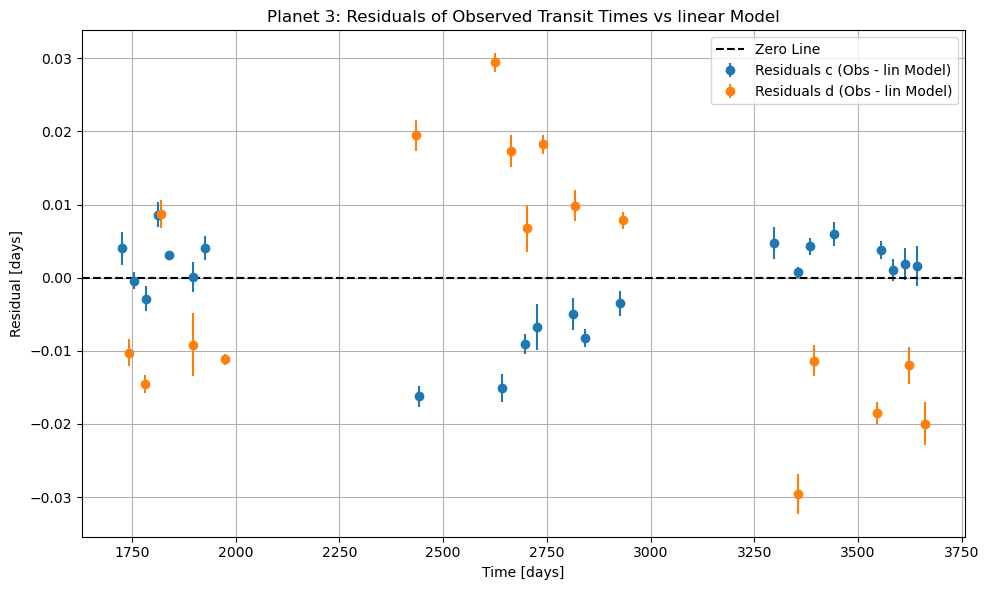

In [241]:
plt.figure(figsize=(10, 6))
plt.errorbar(transit_times_2, residuals_2, yerr=tc_err_2, fmt='o', label='Residuals c (Obs - lin Model)')
plt.errorbar(transit_times_3, residuals_3, yerr=tc_err_3, fmt='o', label='Residuals d (Obs - lin Model)')

plt.axhline(0, color='black', linestyle='--', label='Zero Line')
plt.xlabel('Time [days]')
plt.ylabel('Residual [days]')
plt.title('Planet 3: Residuals of Observed Transit Times vs linear Model')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [242]:
def ttv_sinusoidal_model(t, A, phi, P_super):
    return A * np.sin(2 * np.pi * t / P_super + phi)

def full_ttv_model(n, T0, P, A, phi, m2_over_Mstar, jmax=1):
    """
    Full transit time model including:
    - linear ephemeris
    - sinusoidal resonant TTV
    - synodic chopping signal

    Parameters:
        n : transit epoch (Index)
        T0 : reference transit time
        P : orbital period
        A : amplitude of resonant TTV [days]
        phi : phase of resonant TTV [radians]
        m2_over_Mstar : mass ratio (perturber/star) for chopping signal

    Returns:
        Predicted transit times at epochs n
    """
    # Linear ephemeris
    t_linear = T0 + n * P

    # Resonant TTV (sinusoidal)
    P_super = 1 / abs(3 / P_outer - 2 / P)  # or compute based on best-fit P
    resonant_ttv = A * np.sin(2 * np.pi * t_linear / P_super + phi)

    # Synodic chopping TTV
    alpha = (P / P_outer)**(2/3)
    chopping_ttv = synodic_chopping_ttv(
        t_linear,  # times
        P, P_outer,  # inner = transiting
        m2_over_Mstar,
        alpha,
        transiting='inner',
        jmax=jmax
    )

    return t_linear + resonant_ttv + chopping_ttv  # total predicted Tc

In [243]:
epochs_2 = np.array(indices_2)             # transit numbers
t_obs_2 = np.array(transit_times_2)        # observed transit times
t_err_2 = np.array(tc_err_2)      

In [244]:
from scipy.optimize import curve_fit

# Initial guesses: [T0, P, A, phi, m2/M*]
T0_guess = t_obs_2[0]
P_guess = P_inner  # or refined fit
A_guess = 0.007    # ~1.4 minutes
phi_guess = 0.0
m2_over_Mstar_guess = m_outer_over_Mstar

p0 = [T0_guess, P_guess, A_guess, phi_guess, m2_over_Mstar_guess]

# Fit the model
popt, pcov = curve_fit(
    full_ttv_model,
    epochs_2,
    t_obs_2,
    sigma=t_err_2,
    p0=p0,
    absolute_sigma=True
)

T0_fit, P_fit, A_fit, phi_fit, m2M_fit = popt
T0_err, P_err, A_err, phi_err, m2M_err = np.sqrt(np.diag(pcov))

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_78658/4118552350.py:9: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  db_dalpha = derivative(lambda a: laplace_b_12(a, j), alpha, dx=h, order=5)


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_78658/4118552350.py:9: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  db_dalpha = derivative(lambda a: laplace_b_12(a, j), alpha, dx=h, order=5)


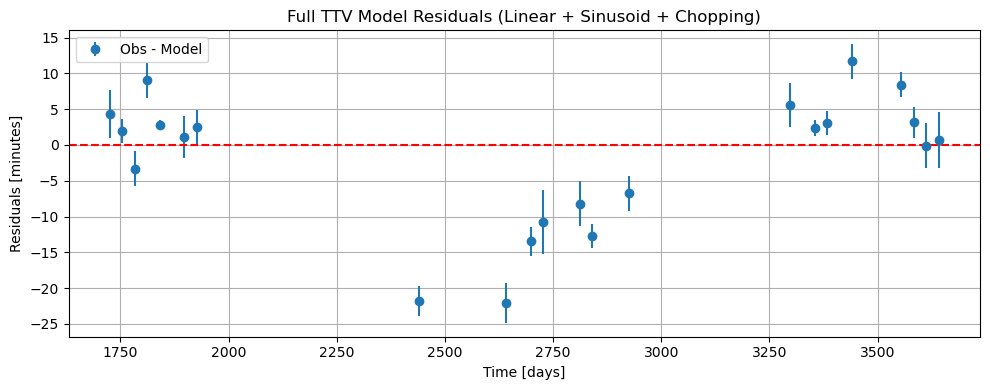

In [245]:
# Compute model transit times
t_model = full_ttv_model(epochs_2, T0_fit, P_fit, A_fit, phi_fit, m2M_fit)

# Residuals
residuals = (t_obs_2 - t_model) * 24 * 60  # minutes
t_err_min = t_err_2 * 24 * 60

plt.figure(figsize=(10, 4))
plt.errorbar(t_obs_2, residuals, yerr=t_err_min, fmt='o', label='Obs - Model')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Time [days]')
plt.ylabel('Residuals [minutes]')
plt.title('Full TTV Model Residuals (Linear + Sinusoid + Chopping)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [249]:
# === Epoch grid ===
n_dense = np.linspace(min(epochs_2) - 1, max(epochs_2) + 1, 1000)
t_dense = T0_fit + n_dense * P_fit

# === Observed TTVs ===
epochs_2 = np.array(indices_2)
t_obs = np.array(transit_times_2)
t_err = np.array(tc_err_2)
t_linear = T0_fit + epochs_2 * P_fit
ttv_obs = (t_obs - t_linear) * 24 * 60  # in minutes
ttv_err = t_err * 24 * 60

# === Harmonic model (dotted) ===
ttv_full_model = (full_ttv_model(n_dense, T0_fit, P_fit, A_fit, phi_fit, m2M_fit) - t_dense) * 24 * 60  # in minutes

# === j=1 chopping only (red) ===
alpha = (P_fit / P_outer)**(2/3)
ttv_chop_j1 = synodic_chopping_ttv(t_dense, P_fit, P_outer, m2M_fit, alpha, transiting='inner', jmax=1) * 24 * 60

# === full chopping (blue) ===
ttv_chop_full = synodic_chopping_ttv(t_dense, P_fit, P_outer, m2M_fit, alpha, transiting='inner', jmax=5) * 24 * 60
# Evaluate j=1 chopping model at observed transit times
ttv_chop_j1_obs = synodic_chopping_ttv(t_obs, P_fit, P_outer, m2M_fit, alpha, transiting='inner', jmax=1)
ttv_chop_j1_obs = ttv_chop_j1_obs * 24 * 60  # convert to minutes

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_78658/4118552350.py:9: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  db_dalpha = derivative(lambda a: laplace_b_12(a, j), alpha, dx=h, order=5)


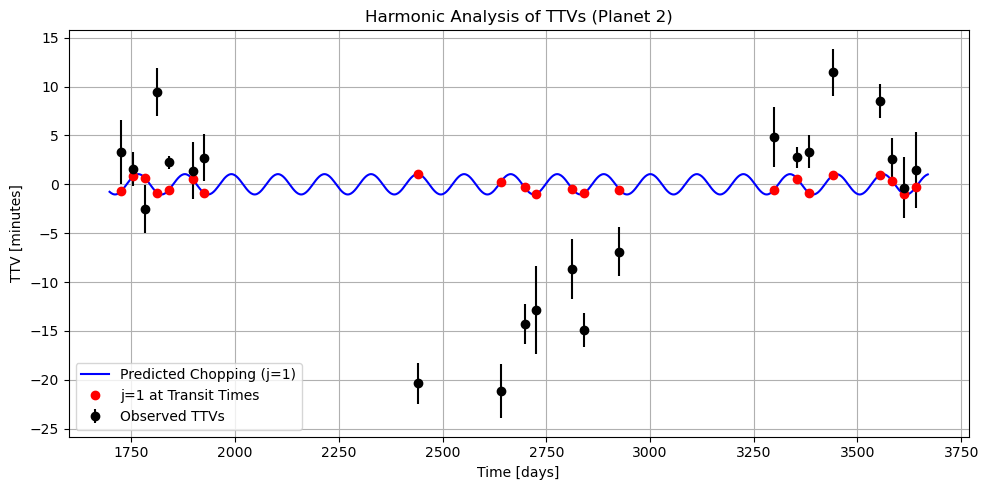

In [252]:
plt.figure(figsize=(10, 5))

# Observed TTVs (black circles)
plt.errorbar(t_linear, ttv_obs, yerr=ttv_err, fmt='o', color='black', label='Observed TTVs')

# Harmonic fit (dotted black)
# plt.plot(t_dense, ttv_full_model, 'k--', label='Full Harmonic Fit')

# j=1 chopping (red)
plt.plot(t_dense, ttv_chop_j1, 'b-', label='Predicted Chopping (j=1)')

plt.plot(t_obs, ttv_chop_j1_obs, 'ro', label='j=1 at Transit Times')

# full chopping (blue)
# plt.plot(t_dense, ttv_chop_full, 'b-', label='Predicted Full Chopping (j=1-5)')

# Labels and formatting
plt.xlabel('Time [days]')
plt.ylabel('TTV [minutes]')
plt.title('Harmonic Analysis of TTVs (Planet 2)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
